# Analyse de la campagne de simulation SPIREC — Graphiques G1 à G6

Ce notebook génère les figures d'évaluation de PADRE à partir du CSV produit par
le serveur de collecte (`server_sim.py`) et des traces d'activité générées
(`traces_preview.csv`).

**Principe** : la vraie sonde PADRE tourne sur chaque ESP32, alimentée par une
activité CPU dérivée du dataset serre et une batterie simulée en boucle fermée.
Le serveur n'a reçu que les trames que PADRE a **décidé** d'émettre ; le taux de
suppression se déduit des sauts de `seq`.

| Fig | Ce qu'elle prouve |
|-----|-------------------|
| G1  | Signal réel vs mesures transmises (filtrage PADRE) |
| G2  | Taux de suppression par profil (adaptativité) |
| G3  | Décharge batterie des 5 équipements (couplage énergie-activité) |
| G4  | Mode survie : émissions ralenties → chute batterie freinée |
| G5  | Réactivité à l'événement critique (décision lexicographique) |
| G6  | Trafic PADRE vs transmission systématique (scalabilité edge) |

**Prérequis** : `pip install pandas numpy matplotlib`. Placer ce notebook dans
le même dossier que `simulation_3h.csv` et `traces_preview.csv`.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Chemins (à adapter au besoin) ---
CSV_RESULTATS = "simulation_3h.csv"     # sortie de server_sim.py
CSV_TRACES    = "traces_preview.csv"    # activité CPU générée
PAS_S = 2                               # période d'un cycle (s)

plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})

# Couleurs cohérentes par profil
COUL = {"stable":"#2a78d6","montee_charge":"#eb6834","critique":"#e34948",
        "batterie_faible":"#1baf7a","nominal":"#6250d6"}
def coul(dev): return COUL.get(dev.replace("sim-",""), "#888")

In [24]:
# --- Chargement ---
df = pd.read_csv(CSV_RESULTATS)
for c in ["seq","cpu_usage_pct","battery_mv","bytes_tx","tx_success_rate","ts_epoch"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["seq","device"]).sort_values(["device","seq"])
t0 = df["ts_epoch"].min()
df["t_min"] = (df["ts_epoch"] - t0) / 60.0
devices = sorted(df["device"].unique())
print("Équipements :", devices)
print("Trames reçues :", len(df))
df.groupby("device")["seq"].agg(count="count", seq_max="max")

Équipements : ['sim-batterie_faible', 'sim-critique', 'sim-montee_charge', 'sim-nominal', 'sim-stable']
Trames reçues : 3687


,count,seq_max
device,,
sim-batterie_faible,84,1246
sim-critique,1136,5371
sim-montee_charge,878,5665
sim-nominal,993,5787
sim-stable,596,5660


## G1 — Signal réel vs mesures transmises

Activité CPU **réelle** (générée, gris) et points **reçus** par le serveur
(couleur). Là où la courbe grise n'a pas de point coloré, PADRE s'est **tu** :
il transmet dans les variations, se tait dans les phases stables.

> **Note** : les points sont placés au **temps réel** (horodatage serveur), et non `seq × 2s`. En mode survie, les cycles s'espacent (jusqu'à 10 s), donc `seq × 2s` sous-estimerait le temps et tasserait les points de l'équipement batterie_faible au début du graphe.

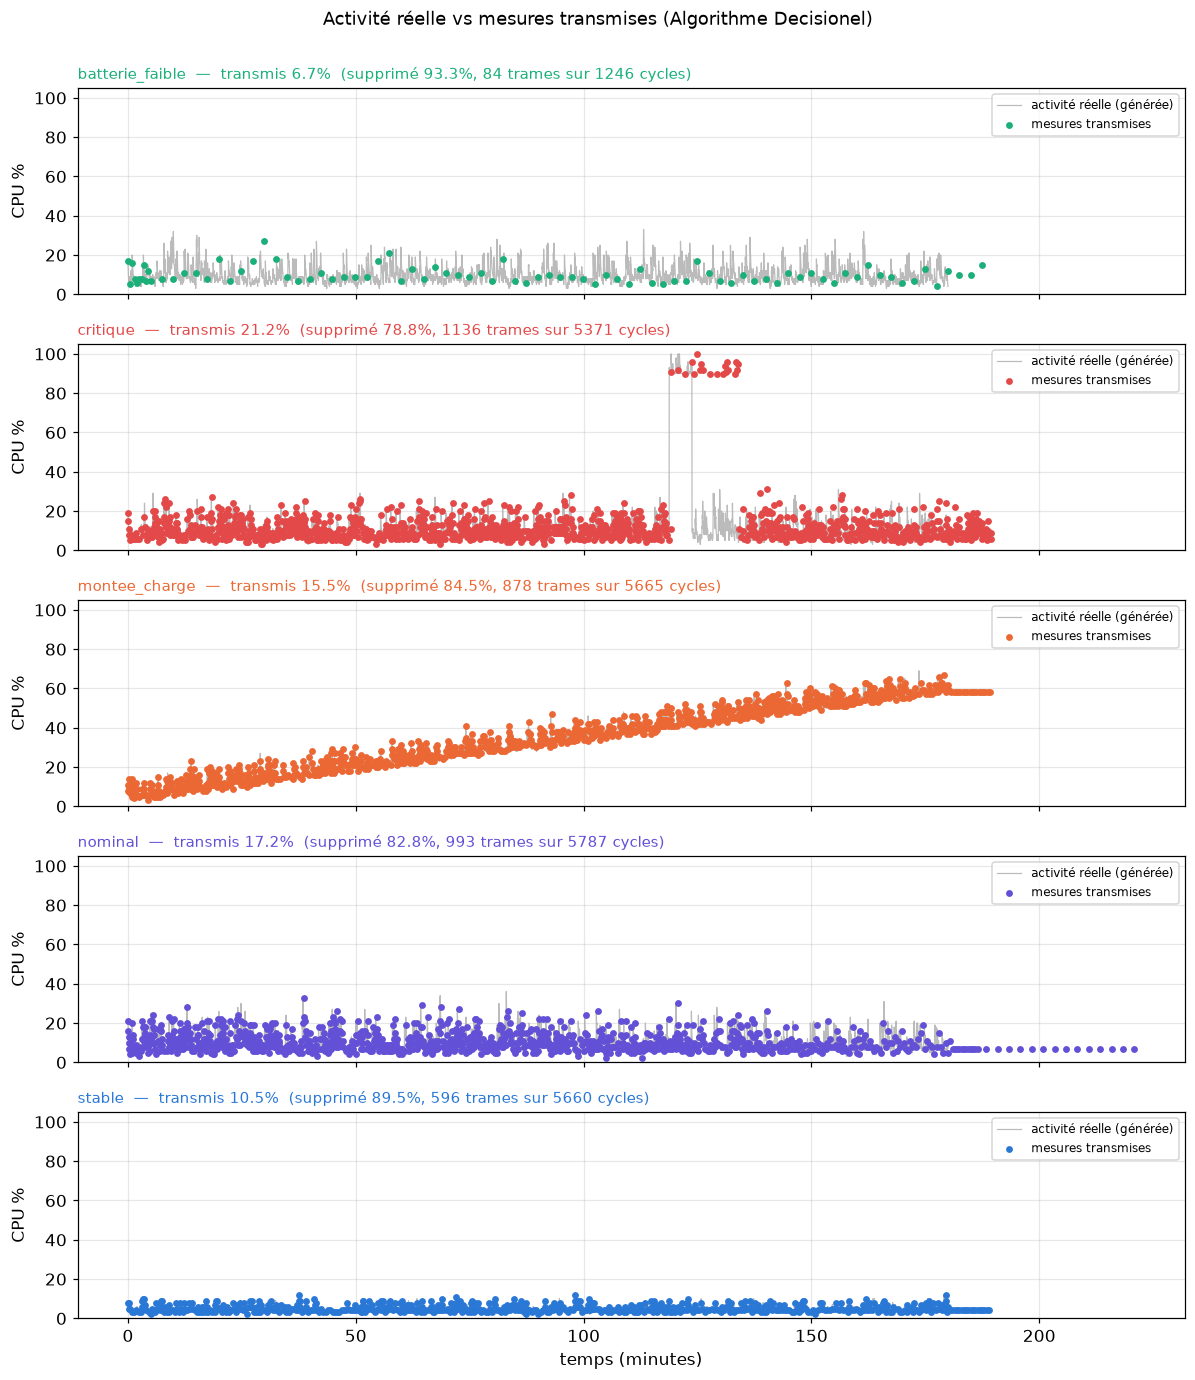

In [25]:
traces = pd.read_csv(CSV_TRACES)
traces["t_min"] = traces["temps_s"] / 60.0

fig, axes = plt.subplots(len(devices), 1, figsize=(11, 2.5*len(devices)), sharex=True)
for ax, dev in zip(axes, devices):
    prof = dev.replace("sim-", "")
    sub = df[df["device"] == dev]
    n = len(sub); seq_max = int(sub["seq"].max())
    tx_pct = 100*n/seq_max; supp_pct = 100 - tx_pct
    if prof in traces.columns:
        ax.plot(traces["t_min"], traces[prof], color="#bbb", lw=0.8,
                label="activité réelle (générée)", zorder=1)
    # Points au VRAI horodatage serveur (t_min), pas seq*2s (cf. note ci-dessus)
    ax.scatter(sub["t_min"], sub["cpu_usage_pct"], s=12,
               color=coul(dev), label="mesures transmises", zorder=3)
    ax.set_ylabel("CPU %"); ax.set_ylim(0, 105)
    # Titre AVEC le taux : rend G1 coherent avec G2 (les points visibles ne
    # sont qu'une fraction des cycles ; le reste est supprime, donc invisible).
    ax.set_title(f"{prof}  —  transmis {tx_pct:.1f}%  (supprimé {supp_pct:.1f}%, "
                 f"{n} trames sur {seq_max} cycles)",
                 loc="left", fontsize=9.5, color=coul(dev))
    ax.legend(fontsize=8, loc="upper right")
axes[-1].set_xlabel("temps (minutes)")
fig.suptitle("Activité réelle vs mesures transmises (Algorithme Decisionel)", y=1.001, fontsize=12)
plt.tight_layout()
plt.savefig("G1_reel_vs_transmis.png", bbox_inches="tight", dpi=130)
plt.show()

## G2 — Taux de suppression par profil

Déduit des sauts de `seq` : sur `seq_max` cycles, la sonde a émis `n` trames,
donc suppression = `1 − n/seq_max`. Un taux élevé = fort filtrage.

,profil,cycles,transmis,suppression_%
0,batterie_faible,1246,84,93.258427
4,stable,5660,596,89.469965
2,montee_charge,5665,878,84.501324
3,nominal,5787,993,82.840850
1,critique,5371,1136,78.849376


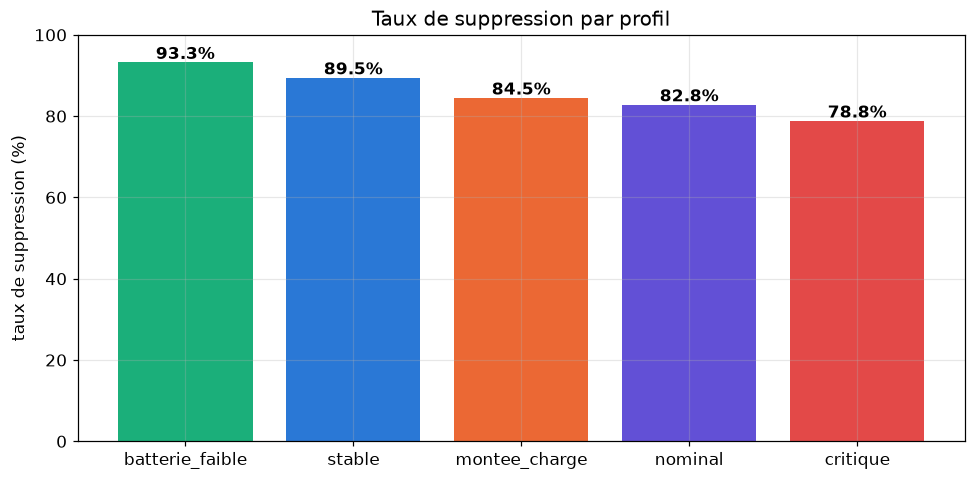

In [26]:
stats = []
for dev in devices:
    sub = df[df["device"] == dev]
    sm = int(sub["seq"].max()); n = len(sub)
    stats.append({"profil": dev.replace("sim-",""), "cycles": sm,
                  "transmis": n, "suppression_%": 100*(1-n/sm)})
S = pd.DataFrame(stats).sort_values("suppression_%", ascending=False)
display(S)

fig, ax = plt.subplots(figsize=(9,4.5))
b = ax.bar(S["profil"], S["suppression_%"],
           color=[coul("sim-"+p) for p in S["profil"]])
for bb, v in zip(b, S["suppression_%"]):
    ax.text(bb.get_x()+bb.get_width()/2, v+0.8, f"{v:.1f}%",
            ha="center", fontweight="bold")
ax.set_ylabel("taux de suppression (%)"); ax.set_ylim(0, 100)
ax.set_title("Taux de suppression par profil")
plt.tight_layout()
plt.savefig("G2_taux_suppression.png", bbox_inches="tight", dpi=130)
plt.show()

## G3 — Décharge de la batterie (5 équipements)

Tension batterie (mV) au fil du temps. Le cutoff PADRE (3300 mV, pointillé)
déclenche le mode survie. La vitesse de décharge dépend de l'activité.

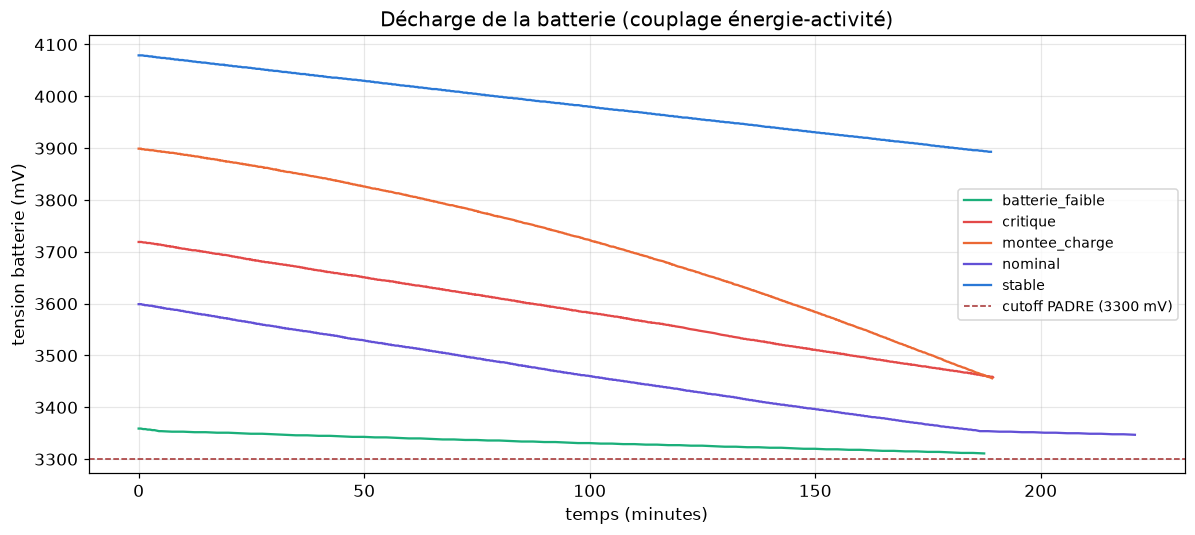

In [27]:
fig, ax = plt.subplots(figsize=(11,5))
for dev in devices:
    sub = df[df["device"] == dev]
    ax.plot(sub["t_min"], sub["battery_mv"], color=coul(dev), lw=1.5,
            label=dev.replace("sim-",""))
ax.axhline(3300, ls="--", color="#a32d2d", lw=1, label="cutoff PADRE (3300 mV)")
ax.set_xlabel("temps (minutes)"); ax.set_ylabel("tension batterie (mV)")
ax.set_title("Décharge de la batterie (couplage énergie-activité)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("G3_decharge_batterie.png", bbox_inches="tight", dpi=130)
plt.show()

## G4 — Mode survie : émissions ralenties → chute freinée

Zoom sur **batterie_faible**. Batterie (mV) et rythme d'émission (trames/5 min)
superposés. Quand la batterie franchit le cutoff, PADRE espace ses émissions :
le rythme chute et la pente de batterie s'adoucit.

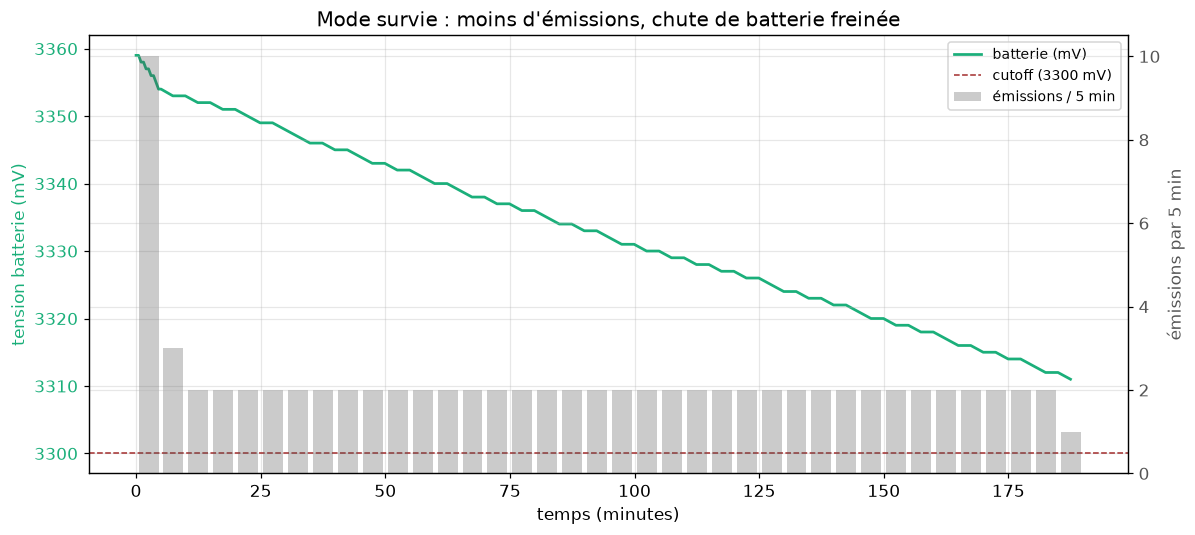

In [28]:
dev = "sim-batterie_faible"
sub = df[df["device"] == dev].sort_values("t_min")
bins = np.arange(0, sub["t_min"].max()+5, 5)
tmp = sub.copy(); tmp["bin"] = pd.cut(tmp["t_min"], bins)
rythme = tmp.groupby("bin", observed=True).size()
centres = [iv.mid for iv in rythme.index]

fig, ax1 = plt.subplots(figsize=(11,5))
ax1.plot(sub["t_min"], sub["battery_mv"], color=coul(dev), lw=1.8, label="batterie (mV)")
ax1.axhline(3300, ls="--", color="#a32d2d", lw=1, label="cutoff (3300 mV)")
ax1.set_xlabel("temps (minutes)"); ax1.set_ylabel("tension batterie (mV)", color=coul(dev))
ax1.tick_params(axis="y", labelcolor=coul(dev))
ax2 = ax1.twinx()
ax2.bar(centres, rythme.values, width=4, alpha=0.3, color="#555", label="émissions / 5 min")
ax2.set_ylabel("émissions par 5 min", color="#555"); ax2.tick_params(axis="y", labelcolor="#555")
ax1.set_title("Mode survie : moins d'émissions, chute de batterie freinée")
l1,la1 = ax1.get_legend_handles_labels(); l2,la2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, la1+la2, fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("G4_mode_survie.png", bbox_inches="tight", dpi=130)
plt.show()

## G5 — Réactivité à l'événement critique

Pour **critique** : instant du pic de saturation CPU (status `cpu_saturated`,
CPU > 90 %). Les alarmes sont transmises **immédiatement**, sans attendre le
heartbeat — la priorité lexicographique en action.

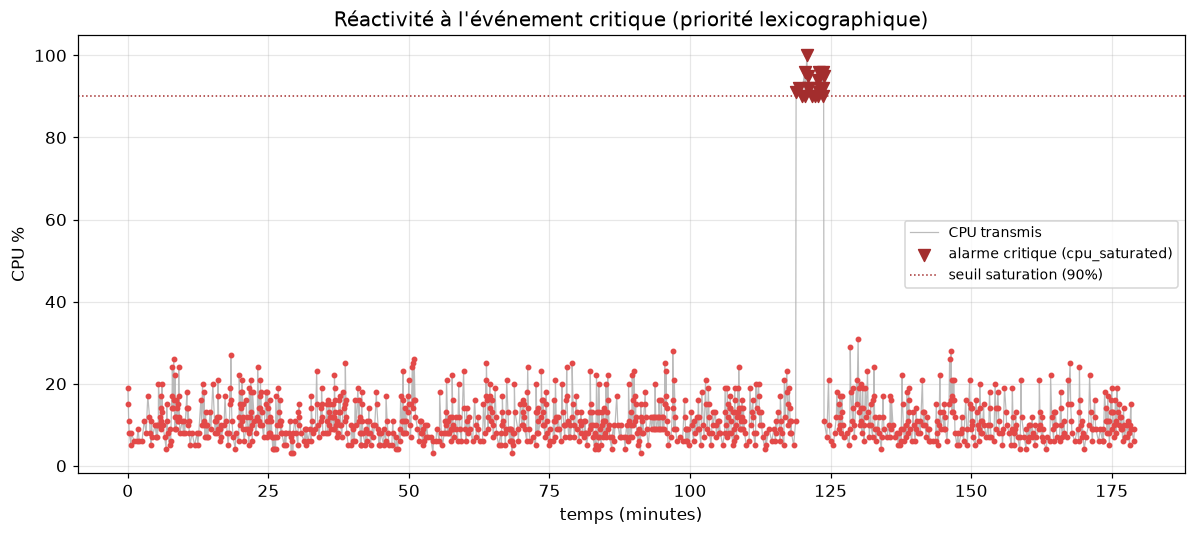

Pic critique à partir de seq=3566 (t=118.9 min), 20 trames d'alarme.


In [29]:
dev = "sim-critique"
sub = df[df["device"] == dev].sort_values("seq")
sub["t_min"] = sub["seq"] * PAS_S / 60.0
crit = sub[sub["status"] == "cpu_saturated"]

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(sub["t_min"], sub["cpu_usage_pct"], color="#bbb", lw=0.8, zorder=1, label="CPU transmis")
ax.scatter(sub["t_min"], sub["cpu_usage_pct"], s=8, color=coul(dev), zorder=2)
ax.scatter(crit["t_min"], crit["cpu_usage_pct"], s=60, marker="v",
           color="#a32d2d", zorder=3, label="alarme critique (cpu_saturated)")
ax.axhline(90, ls=":", color="#a32d2d", lw=1, label="seuil saturation (90%)")
ax.set_xlabel("temps (minutes)"); ax.set_ylabel("CPU %")
ax.set_title("Réactivité à l'événement critique (priorité lexicographique)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("G5_reactivite_critique.png", bbox_inches="tight", dpi=130)
plt.show()
if len(crit):
    print(f"Pic critique à partir de seq={int(crit['seq'].min())} "
          f"(t={crit['t_min'].min():.1f} min), {len(crit)} trames d'alarme.")

## G6 — Trafic PADRE vs transmission systématique

Nombre de trames émises par PADRE vs transmission systématique (`seq_max`, une
par cycle). La réduction montre le soulagement du serveur edge : PADRE permet de
superviser bien plus d'équipements à capacité serveur égale.

,profil,systématique,PADRE,réduction_%
0,batterie_faible,1246,84,93.258427
1,critique,5371,1136,78.849376
2,montee_charge,5665,878,84.501324
3,nominal,5787,993,82.840850
4,stable,5660,596,89.469965


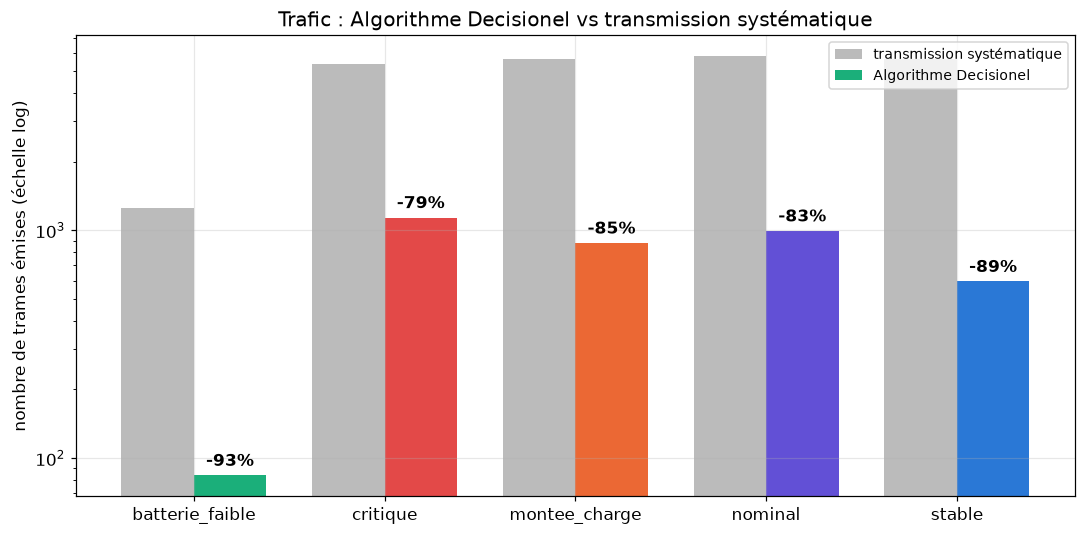

Total : systématique 23729, PADRE 3687 -> réduction globale 84.5%


In [31]:
comp = []
for dev in devices:
    sub = df[df["device"] == dev]
    sm = int(sub["seq"].max()); n = len(sub)
    comp.append({"profil": dev.replace("sim-",""), "systématique": sm,
                 "PADRE": n, "réduction_%": 100*(1-n/sm)})
C = pd.DataFrame(comp)
display(C)

x = np.arange(len(C)); w = 0.38
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x-w/2, C["systématique"], w, color="#bbb", label="transmission systématique")
ax.bar(x+w/2, C["PADRE"], w, color=[coul("sim-"+p) for p in C["profil"]], label="Algorithme Decisionel")
ax.set_xticks(x); ax.set_xticklabels(C["profil"])
ax.set_ylabel("nombre de trames émises (échelle log)"); ax.set_yscale("log")
ax.set_title("Trafic : Algorithme Decisionel vs transmission systématique")
ax.legend(fontsize=9)
for i,(s,p) in enumerate(zip(C["systématique"], C["PADRE"])):
    ax.text(i+w/2, p*1.1, f"-{100*(1-p/s):.0f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("G6_trafic_compare.png", bbox_inches="tight", dpi=130)
plt.show()
ts, tp = C["systématique"].sum(), C["PADRE"].sum()
print(f"Total : systématique {ts}, PADRE {tp} -> réduction globale {100*(1-tp/ts):.1f}%")

## Synthèse

Les six figures sont sauvegardées en PNG haute résolution (prêtes pour le
mémoire). Elles démontrent : le filtrage adaptatif (G1), son ampleur par profil
(G2), le couplage énergie-activité (G3), la régulation énergétique en mode
survie (G4), la réactivité aux alarmes critiques (G5), et le bénéfice pour
l'infrastructure edge (G6).

Sur cette campagne : réduction globale du trafic de ~84,5 %, taux de suppression
de 79 % (critique) à 93 % (batterie faible), mode survie effectif sur
l'équipement en fin de batterie.